In [ ]:
!pip install -q opencv-python-headless

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import cv2
import tensorflow as tf
from tensorflow.keras import layers, models, optimizers
from tensorflow.keras.datasets import mnist
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix

RANDOM_STATE = 42
tf.random.set_seed(RANDOM_STATE)
np.random.seed(RANDOM_STATE)

In [ ]:
(X_train_full, y_train_full), (X_test, y_test) = mnist.load_data()
X_train_full = X_train_full.astype("float32") / 255.0
X_test = X_test.astype("float32") / 255.0

# X_train_full = X_train_full.reshape(-1, 784)
# X_test = X_test.reshape(-1, 784)

X_train_full = np.expand_dims(X_train_full, -1)
X_test = np.expand_dims(X_test, -1)

y_train_full_cat = to_categorical(y_train_full, 10)
y_test_cat = to_categorical(y_test, 10)

# X_train, y_train = X_train_full, y_train_full_cat

X_train, X_val, y_train, y_val = train_test_split(
    X_train_full, y_train_full_cat, test_size=0.1, random_state=RANDOM_STATE
)

# print(f"Train: {X_train.shape}, Val: {X_validation.shape}, Test: {X_test.shape}")

print(f"Train: {X_train.shape}, Val: {X_val.shape}, Test: {X_test.shape}")

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Train: (54000, 28, 28, 1), Val: (6000, 28, 28, 1), Test: (10000, 28, 28, 1)


In [ ]:
def build_cnn(input_shape=(28, 28, 1), num_classes=10):
  # input_shape=(28, 28)


    model = models.Sequential([
        layers.Input(shape=input_shape),
        layers.Conv2D(32, (3, 3), padding="same", activation="relu"),
        layers.BatchNormalization(),
        layers.Conv2D(32, (3, 3), padding="same", activation="relu"),
        layers.BatchNormalization(),
        layers.MaxPooling2D((2, 2)),
        layers.Dropout(0.25),
        layers.Conv2D(64, (3, 3), padding="same", activation="relu"),
        layers.BatchNormalization(),
        layers.Conv2D(64, (3, 3), padding="same", activation="relu"),
        layers.BatchNormalization(),
        layers.MaxPooling2D((2, 2)),
        layers.Dropout(0.25),
        # layers.Flatten(),



        layers.GlobalAveragePooling2D(),
        layers.Dense(128, activation="relu"),
        layers.BatchNormalization(),
        # layers.Dropout(0.5),


        layers.Dropout(0.4),
        layers.Dense(num_classes, activation="softmax"),
    ], name="ocr_cnn")
    model.compile(optimizer=optimizers.Adam(1e-3), loss="categorical_crossentropy", metrics=["accuracy"])
    return model

model = build_cnn()
model.summary()

Model: "ocr_cnn"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 28, 28, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 28, 28, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 28, 28, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 28, 28, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 14, 14, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 14, 14, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 14, 14, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 14, 14, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 64)             │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 75,882 (296.41 KB)

 Trainable params: 75,242 (293.91 KB)

 Non-trainable params: 640 (2.50 KB)

In [ ]:
callbacks = [
    EarlyStopping(monitor="val_loss", patience=4, restore_best_weights=True),
    ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=2, min_lr=1e-6),
]

history = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=15,
    batch_size=128,
    callbacks=callbacks,
    verbose=2,
)

Epoch 1/15
422/422 - 22s - 51ms/step - accuracy: 0.8660 - loss: 0.4228 - val_accuracy: 0.2252 - val_loss: 3.2724 - learning_rate: 0.0010
Epoch 2/15
422/422 - 4s - 10ms/step - accuracy: 0.9642 - loss: 0.1195 - val_accuracy: 0.9680 - val_loss: 0.1041 - learning_rate: 0.0010
Epoch 3/15
422/422 - 4s - 9ms/step - accuracy: 0.9753 - loss: 0.0821 - val_accuracy: 0.9810 - val_loss: 0.0632 - learning_rate: 0.0010
Epoch 4/15
422/422 - 4s - 9ms/step - accuracy: 0.9803 - loss: 0.0667 - val_accuracy: 0.9810 - val_loss: 0.0612 - learning_rate: 0.0010
Epoch 5/15
422/422 - 4s - 10ms/step - accuracy: 0.9825 - loss: 0.0587 - val_accuracy: 0.9705 - val_loss: 0.0986 - learning_rate: 0.0010
Epoch 6/15
422/422 - 4s - 10ms/step - accuracy: 0.9845 - loss: 0.0510 - val_accuracy: 0.9893 - val_loss: 0.0303 - learning_rate: 0.0010
Epoch 7/15
422/422 - 4s - 10ms/step - accuracy: 0.9849 - loss: 0.0480 - val_accuracy: 0.9882 - val_loss: 0.0399 - learning_rate: 0.0010
Epoch 8/15
422/422 - 4s - 11ms/step - accuracy: 0

Test accuracy: 0.9939 | Test loss: 0.0186
              precision    recall  f1-score   support

           0       1.00      0.99      1.00       980
           1       0.99      1.00      0.99      1135
           2       1.00      1.00      1.00      1032
           3       0.99      0.99      0.99      1010
           4       0.99      1.00      0.99       982
           5       0.99      0.99      0.99       892
           6       0.99      0.99      0.99       958
           7       1.00      0.99      0.99      1028
           8       0.99      1.00      1.00       974
           9       1.00      0.99      0.99      1009

    accuracy                           0.99     10000
   macro avg       0.99      0.99      0.99     10000
weighted avg       0.99      0.99      0.99     10000



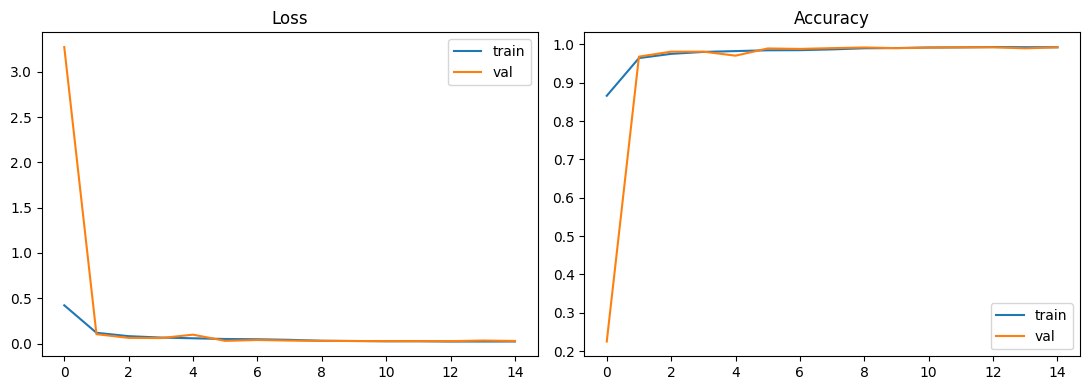

In [ ]:
# test_loss, test_acc = model.evaluate(X_test, y_test, verbose=0)
test_loss, test_acc = model.evaluate(X_test, y_test_cat, verbose=0)
print(f"Test accuracy: {test_acc:.4f} | Test loss: {test_loss:.4f}")
y_pred = np.argmax(model.predict(X_test, verbose=0), axis=1)
print(classification_report(y_test, y_pred))
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
# axes[0].plot(history.history["train_loss"], label="train")
# axes[1].plot(history.history["acc"], label="train"); axes[1].plot(history.history["val_acc"], label="val")


axes[0].plot(history.history["loss"], label="train"); axes[0].plot(history.history["val_loss"], label="val")
axes[0].set_title("Loss"); axes[0].legend()
axes[1].plot(history.history["accuracy"], label="train"); axes[1].plot(history.history["val_accuracy"], label="val")


axes[1].set_title("Accuracy"); axes[1].legend()
plt.tight_layout(); plt.show()

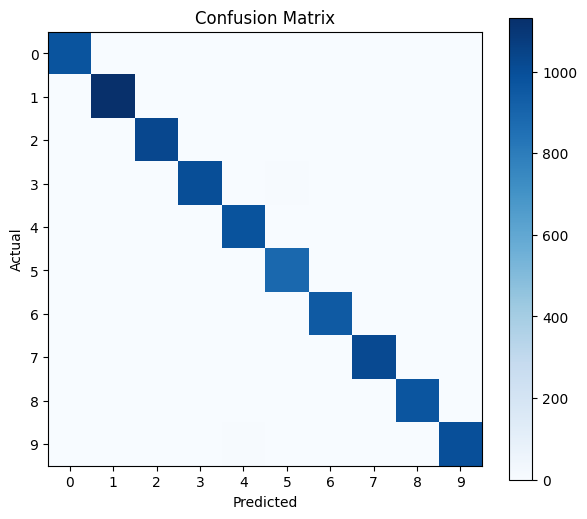

In [ ]:
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(7, 6))
plt.imshow(cm, cmap="Blues")
plt.xticks(range(10)); plt.yticks(range(10))
plt.xlabel("Predicted"); plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.colorbar()
plt.show()

In [ ]:
def prepare_character(crop, img_size=28):
    if crop.ndim == 3:
        crop = cv2.cvtColor(crop, cv2.COLOR_BGR2GRAY)
    h, w = crop.shape
    size = max(h, w)

    #if h == size:
        #pad_top, pad_bottom = 0, 0
        #pad_left, pad_right = (size - w) // 2, (size - w) // 2
    #else:
        #pad_top, pad_bottom = (size - h) // 2, (size - h) // 2
        #pad_left, pad_right = 0, 0




    padded = np.zeros((size, size), dtype=crop.dtype)
    y_off, x_off = (size - h) // 2, (size - w) // 2
    padded[y_off:y_off+h, x_off:x_off+w] = crop
    resized = cv2.resize(padded, (img_size, img_size))
    normalized = resized.astype("float32") / 255.0
    return np.expand_dims(normalized, axis=-1)

def segment_characters(image, min_contour_area=20):
    gray = image if image.ndim == 2 else cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
    _, binary = cv2.threshold(gray, 0, 255, cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU)
    contours, _ = cv2.findContours(binary, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    boxes = [cv2.boundingRect(c) for c in contours if cv2.contourArea(c) > min_contour_area]
    boxes.sort(key=lambda b: b[0])
    return boxes

def predict_word(model, image, min_contour_area=20):


    #image = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
    #_, image = cv2.threshold(image, 0, 255, cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU)
    #contours, _ = cv2.findContours(image, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    #boxes = [cv2.boundingRect(c) for c in contours if cv2.contourArea(c) > min_contour_area]
    #boxes.sort(key=lambda b: b[0])
    #if not boxes:
        #return ""


    boxes = segment_characters(image, min_contour_area)
    if not boxes:
        return ""
    prediction = ""
    for (x, y, w, h) in boxes:
        crop = image[y:y+h, x:x+w]
        probs = model.predict(prepare_character(crop)[np.newaxis, ...], verbose=0)[0]
        prediction += str(int(np.argmax(probs)))
    return prediction

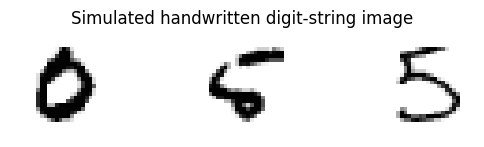

Predicted word/string: 8808
Ground truth: 055


In [ ]:
demo_indices = [3, 8, 15]
digit_imgs = [(255 - (X_test[i].squeeze() * 255)).astype("uint8") for i in demo_indices]
canvas = np.full((28, 28 * len(digit_imgs) + 20 * (len(digit_imgs) - 1)), 255, dtype="uint8")
for idx, img in enumerate(digit_imgs):
    start = idx * (28 + 20)
    canvas[:, start:start+28] = img
plt.figure(figsize=(6, 2))
plt.imshow(canvas, cmap="gray")
plt.title("Simulated handwritten digit-string image")
plt.axis("off")
plt.show()
result = predict_word(model, canvas)
print("Predicted word/string:", result)
print("Ground truth:", "".join(str(y_test[i]) for i in demo_indices))

In [ ]:
import os
os.makedirs("models", exist_ok=True)
model.save("models/ocr_cnn_best.keras")
print("Saved models/ocr_cnn_best.keras")

Saved models/ocr_cnn_best.keras
